# 061 — Design-group MSA-FEMAP695 collapse fragilities

Collects the **MSA-FEMAP695** collapse fragility of every design group from the analysis
drive, copies it into the processed-data tree **with a provenance manifest**, plots it
against its stripe IMLs, reports which curves are *not well defined*, and then **fans
each group's fragility back out to every member site**.

This is notebook `060` done per **design group** instead of per site, with `053`'s
fan-out bolted on the end:

| arm | records | run per | processed by |
|---|---|---|---|
| MSA | 30 GCIM records, different at every stripe and site | site | `060` |
| IDA (`ida_femap695`) | 22 FEMA P695 records, hunt-trace-fill | design group | `053` |
| **MSA-FEMAP695** | 22 FEMA P695 records, the same at every stripe | design group | **this notebook** |

Notebook `051` showed the 120 (site, storey) designs collapse to **51 unique designs**
(25 × 3s, 26 × 5s). Because the FEMA P695 record set does not depend on the site, the
MSA-FEMAP695 analysis depends only on the structure, so `054` runs it once per group at
`D:/08_wp1_fixed_record_sets/group_{n}s_{gid}/{n}s/mdof/msa_AvgSA_03_femap695/`.

## Inputs

- `{GROUP_ROOT}/group_{n}s_{gid}/{n}s/mdof/msa_AvgSA_03_femap695/collapse_fragility.json`
  — the MSA run output (`median`, `dispersion`, and the 2×N empirical curve `efc`), `054`.
- `unique_structural_designs.csv` (nb `051`) — the (site, storey) → group table.
- `results/04_record_selection/AvgSA_03_FEMAP695/group_folder_map.csv` (nb `054`) —
  cross-checked, not required.
- `ec8_gen2_site_specific_cbfs.pickle` (nb `011`) — the structure tag of each site, which
  is what the per-site filenames are built from.

## Outputs

| Path | Content |
|---|---|
| `…/09_structure_fragility_curves/wp1_design_groups/group_{n}s_{gid}/group_{n}s_{gid}_msa_femap695_collapsefragility_AvgSA_03.json` | the group fragility (+ manifest) |
| `…/09_structure_fragility_curves/wp1_casestudy_sites/site_{ii}/{tag}_msa_femap695_collapsefragility_AvgSA_03.json` | the per-site copy (+ manifest) |
| `…/wp1_design_groups/group_msa_femap695_collapsefragility_summary.csv` | group-level table |
| `…/wp1_casestudy_sites/site_msa_femap695_collapsefragility_summary.csv` | site-level table |
| `…/wp1_design_groups/group_msa_femap695_additional_stripes.csv` | the extra stripes §4 asks for, read back by `054` |
| `results/07_group_msa_femap695/fragility_curves_group_{n}s_{gid}.jpg` | one fragility figure per group |

The per-site filenames follow the `{tag}_{arm}_collapsefragility_AvgSA_03.json`
convention `060` (`msa`) and `014`/`053` (`ida_femap695`) already use, with the new arm
token `msa_femap695`. `069` reads only the first two suffixes, so the files written here
are inert to it until its loader learns the third arm — a separate job.

## Units

**No gravity rescale here.** `053` divides the IDA collapse IMLs by `GRAVITY` because the
IDA works in mm/s²; `054`'s stripes are built from a fragility median already in **g**, so
`cond_iml`, the fitted median and `efc[0]` are all in g and the fragility is copied
verbatim — exactly as `060` copies the site-specific MSA.

## Caching

Each group is cached against the **content hash of its source `collapse_fragility.json`**,
via `cache_utils.json_load_or_compute`. The analysed IMLs live inside that file as
`efc[0]`, so its hash already pins which stripes the curve was fitted to. The per-site
copies fingerprint the **group** fragility JSON instead — a site file is stale exactly
when its group's fragility changed. Set `FORCE_RECOMPUTE = True` to rebuild everything.

> **Run order.** `011` → `051` → `054` (+ the MSA runs) → **061** → `069`.
> The MSA results live on `D:` — run this on the machine with the drive attached. Without
> it the notebook prints a warning and falls back to the group copies already in
> `data_processed/09_…/wp1_design_groups`, so the report, the plots and the fan-out still
> work, but no group fragility is (re)written.

## Open questions, and the assumption taken for each

| # | Question | Assumption taken | If it is wrong |
|---|---|---|---|
| 1 | Per-**group** or per-**site** files? | **Both.** The group file is the cached artefact; it is then copied to every member site, so anything downstream keeps working on per-site paths. | `FANOUT_TO_SITES = False` writes only the group files. |
| 2 | What is the new arm called on disk? | **`msa_femap695`**, i.e. `{tag}_msa_femap695_collapsefragility_AvgSA_03.json`, alongside the existing `msa` and `ida_femap695` files. | Edit `MSA_TAG`. |
| 3 | Should a badly conditioned group be withheld from the fan-out? | **No.** §4 reports which groups' stripes fail to bracket collapse and both summary CSVs carry the flag, but every group is fanned out. | Filter `group_results` on `well_defined` before §5. |
| 4 | How is a badly conditioned group remediated? | §4 writes the IML each failing tail needs to `group_msa_femap695_additional_stripes.csv`, aimed at **P[C] = 0.15 / 0.85** so the new stripe clears the 0.2 / 0.8 band with a buffer; `054` reads that file and runs the extra stripes. None of `060` §5's reserves / disaggregation grid applies — there is no hazard curve behind these stripes. | Edit `REMEDIATION_POCS`. |
| 5 | Which storey counts? | **3 and 5.** Only the 3s groups have stripes so far (`054` needs an `ida_femap695` AvgSA_03 fragility per group, which `053` produces); 5s groups are reported and skipped until then. | Edit `STOREYS`. |
| 6 | Should a missing group MSA be an error? | **No** — reported and skipped, so the notebook stays useful while the runs trickle in. | `STRICT = True` raises instead. |

## 0. Setup & parameters

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.stats import lognorm

from phd_project.config import config
from phd_project.scripts.cache_utils import fingerprint, json_load_or_compute
from phd_project.scripts.WP1_ground_motion_set.design_groups import load_design_groups

cfg = config.load_config()

In [3]:
# ----------------------------------------------------------------------------
# PARAMETERS
# ----------------------------------------------------------------------------
GM_SET = "AvgSA_03"          # the conditioning IM of the stripes
RECORD_SET = "femap695"      # the fixed record set
STOREYS = [3, 5]

# The filename token for this arm, alongside "msa" (nb 060) and "ida_femap695" (nb 053).
MSA_TAG = f"msa_{RECORD_SET}"                       # msa_femap695
# The results folder nb 054 told the MSA runner to write into.
RESULTS_FOLDER_NAME = f"msa_{GM_SET}_{RECORD_SET}"  # msa_AvgSA_03_femap695

# --- inputs ---
# Root of the per-DESIGN-GROUP analysis folders (nb 052 / 054). Per group the
# MSA-FEMAP695 run lives at GROUP_ROOT/group_{n}s_{gid}/{n}s/mdof/{RESULTS_FOLDER_NAME}/.
GROUP_ROOT = Path(cfg["analysis_data"]["wp1_fixed_record_sets"])
# nb 054's group -> member-site map. Cross-checked against nb 051's table; not required.
GROUP_MAP_PATH = (Path(cfg["results"][f"{GM_SET}_FEMAP695_record_selection"])
                  / "group_folder_map.csv")
# Site dataset (nb 011): the structure tag of each site.
SITE_DATASET = Path(cfg["proc_data"]["site_specific_dataset"])

# --- outputs ---
GROUP_OUT_ROOT = Path(cfg["proc_data"]["wp1_groups_fragility_curves"])
OUT_ROOT = Path(cfg["proc_data"]["wp1_sites_fragility_curves"])
FIG_ROOT = Path(cfg["results"]["group_msa_femap695"])
GROUP_SUMMARY_CSV = Path(cfg["proc_data"]["wp1_groups_msa_femap695_fc_summary"])
SITE_SUMMARY_CSV = Path(cfg["proc_data"]["wp1_sites_msa_femap695_fc_summary"])

for _d in (GROUP_OUT_ROOT, OUT_ROOT, FIG_ROOT):
    _d.mkdir(parents=True, exist_ok=True)

# Copy each group fragility out to every member site. False writes only the group files.
FANOUT_TO_SITES = True

# Raise instead of skipping when a group has no MSA output on disk.
STRICT = False

# Re-copy and re-plot everything, ignoring the manifests.
FORCE_RECOMPUTE = False

# --- WELL-DEFINEDNESS THRESHOLDS (nb 060) ---
# A curve is well defined only if its stripes bracket collapse: the empirical curve must
# rise ABOVE PC_UPPER_THRESHOLD and start BELOW PC_LOWER_THRESHOLD.
PC_UPPER_THRESHOLD = 0.8
PC_LOWER_THRESHOLD = 0.2

# --- REMEDIATION (section 4) ---
# Where an extra stripe is aimed, per tail. Deliberately OUTSIDE the pass/fail thresholds
# above: a stripe aimed at exactly 0.80 has an even chance of coming back below it, so the
# curve would still not be bracketed and another round would be needed. 0.15 / 0.85 leaves
# a buffer, so one more MSA round is enough.
REMEDIATION_POCS = {"low": 0.15, "high": 0.85}

# Resolution of the suggested IMLs. nb 054's iml_filename_tag encodes 3 decimals, so
# rounding here means the value in the file is exactly the value in the stripe filename.
IML_DECIMALS = 3

# The suggestions nb 054 reads back. Always (re)written by section 4, empty when every
# group is well defined, so nb 054 can never pick up a stale list.
ADDITIONAL_STRIPES_CSV = Path(cfg["proc_data"]["wp1_groups_msa_femap695_additional_stripes"])

print(f"GROUP_ROOT     = {GROUP_ROOT}")
print(f"GROUP_OUT_ROOT = {GROUP_OUT_ROOT}")
print(f"OUT_ROOT       = {OUT_ROOT}  (fan-out: {FANOUT_TO_SITES})")
print(f"FIG_ROOT       = {FIG_ROOT}")

GROUP_ROOT     = D:\08_wp1_fixed_record_sets
GROUP_OUT_ROOT = C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups
OUT_ROOT       = C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_casestudy_sites  (fan-out: True)
FIG_ROOT       = C:\Users\clemettn\Documents\phd\results\07_group_msa_femap695


## 1. Design groups and their MSA folders

One row per design group from `051` (`is_representative == True`), with its member sites.
The folder convention is `054`'s:
`GROUP_ROOT/group_{n}s_{gid:02d}/{n}s/mdof/msa_AvgSA_03_femap695`.

Three checks run here:

- every group is non-empty and every (site, storey) belongs to exactly one group;
- the member lists cover every site of each storey count in `STOREYS`;
- the derived folders agree with `054`'s `group_folder_map.csv` where that file covers
  them. A group `054` skipped (no stripes yet) is simply absent from the map and is
  reported, not treated as a disagreement.

In [4]:
groups_df = load_design_groups(cfg)
groups_df = groups_df[groups_df["storeys"].isin(STOREYS)].copy()

groups = (groups_df[groups_df["is_representative"]]
          .loc[:, ["storeys", "group_id", "representative_site", "representative_tag",
                   "n_sites_in_group"]]
          .sort_values(["storeys", "group_id"])
          .reset_index(drop=True))

members = (groups_df.groupby(["storeys", "group_id"])["site"]
           .apply(lambda s: sorted(int(x) for x in s)))


def group_folder_name(n: int, gid: int) -> str:
    """Folder for a design group: group_3s_00, group_5s_07, ... (nb 052/054's convention)."""
    return f"group_{int(n)}s_{int(gid):02d}"


def group_msa_folder(n: int, gid: int) -> Path:
    """The MSA-FEMAP695 results folder of one design group, on the analysis drive."""
    return (GROUP_ROOT / group_folder_name(n, gid) / f"{int(n)}s" / "mdof"
            / RESULTS_FOLDER_NAME)


def fmt_sites(sites) -> str:
    """Compact, sorted site listing for the printed summaries."""
    return ", ".join(str(s) for s in sorted(sites)) if len(sites) else "-"


# --- sanity checks on the grouping itself ---
dupes = int(groups_df.duplicated(subset=["storeys", "site"]).sum())
assert dupes == 0, f"{dupes} (site, storey) pairs appear in more than one group"
assert (groups["n_sites_in_group"] > 0).all(), "a group has no member sites"

for n in STOREYS:
    all_sites = sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
    from_members = sorted(s for gid in groups.loc[groups["storeys"] == n, "group_id"]
                          for s in members[(n, int(gid))])
    assert from_members == all_sites, f"{n}s: member lists do not cover every site once"
    print(f"{n}s: {int((groups['storeys'] == n).sum()):2d} design groups covering "
          f"{len(all_sites)} sites (site {min(all_sites)}..{max(all_sites)})")

groups["msa_folder"] = [group_msa_folder(r.storeys, r.group_id)
                        for r in groups.itertuples()]
groups["msa_exists"] = [p.is_dir() for p in groups["msa_folder"]]
print(f"\n{int(groups['msa_exists'].sum())}/{len(groups)} group(s) have MSA output on disk")
if not GROUP_ROOT.exists():
    print(f"NOTE: {GROUP_ROOT} is not reachable - the analysis drive is detached.")
groups.head()

3s: 25 design groups covering 60 sites (site 0..59)
5s: 26 design groups covering 60 sites (site 0..59)

0/51 group(s) have MSA output on disk
NOTE: D:\08_wp1_fixed_record_sets is not reachable - the analysis drive is detached.


,storeys,group_id,representative_site,representative_tag,n_sites_in_group,msa_folder,msa_exists
0,3,0,0,3s_cbf_dc2_site0,8,D:\08_wp1_fixed_record_sets\group_3s_00\3s\mdo...,False
1,3,1,1,3s_cbf_dc2_site1,6,D:\08_wp1_fixed_record_sets\group_3s_01\3s\mdo...,False
2,3,2,3,3s_cbf_dc2_site3,1,D:\08_wp1_fixed_record_sets\group_3s_02\3s\mdo...,False
3,3,3,7,3s_cbf_dc2_site7,5,D:\08_wp1_fixed_record_sets\group_3s_03\3s\mdo...,False
4,3,4,9,3s_cbf_dc2_site9,3,D:\08_wp1_fixed_record_sets\group_3s_04\3s\mdo...,False


In [5]:
# --- cross-check the derived folders against nb 054's group map ---
if not GROUP_MAP_PATH.is_file():
    print(f"no group map at {GROUP_MAP_PATH} (nb 054 not run here) - skipping cross-check")
else:
    gmap = pd.read_csv(GROUP_MAP_PATH)
    gmap = gmap[gmap["storeys"].isin(STOREYS)]
    mapped = {(int(r.storeys), int(r.group_id)): r for r in gmap.itertuples()}
    mismatch, unmapped = [], []
    for r in groups.itertuples():
        key = (int(r.storeys), int(r.group_id))
        m = mapped.get(key)
        if m is None:
            # nb 054 skips a group whose representative has no ida_femap695 fragility yet,
            # so it never got stripes and never reached the map. Not a disagreement.
            unmapped.append(key)
            continue
        # nb 054 stores the mdof folder; the MSA results folder is that + RESULTS_FOLDER_NAME.
        expect = (Path(m.folder) / RESULTS_FOLDER_NAME).as_posix().lower()
        if Path(r.msa_folder).as_posix().lower() != expect:
            mismatch.append(f"{group_folder_name(*key)}: {r.msa_folder} != {expect}")
        if int(m.representative_site) != int(r.representative_site):
            mismatch.append(f"{group_folder_name(*key)}: representative site differs")
        if sorted(int(s) for s in str(m.sites).split()) != members[key]:
            mismatch.append(f"{group_folder_name(*key)}: member sites differ")
    if mismatch:
        raise AssertionError("group map disagrees with nb 051's table:\n  "
                             + "\n  ".join(mismatch))
    print(f"group map agrees with nb 051 for all {len(groups) - len(unmapped)} mapped "
          f"group(s): folders, representatives and member lists")
    if unmapped:
        print(f"{len(unmapped)} group(s) are not in the map at all - nb 054 had no stripes "
              f"for them, so they have no MSA run: "
              f"{', '.join(group_folder_name(*k) for k in unmapped)}")

group map agrees with nb 051 for all 25 mapped group(s): folders, representatives and member lists
26 group(s) are not in the map at all - nb 054 had no stripes for them, so they have no MSA run: group_5s_00, group_5s_01, group_5s_02, group_5s_03, group_5s_04, group_5s_05, group_5s_06, group_5s_07, group_5s_08, group_5s_09, group_5s_10, group_5s_11, group_5s_12, group_5s_13, group_5s_14, group_5s_15, group_5s_16, group_5s_17, group_5s_18, group_5s_19, group_5s_20, group_5s_21, group_5s_22, group_5s_23, group_5s_24, group_5s_25


In [6]:
# --- structure tags (nb 011): what the per-site filenames are built from ---
designs = pd.read_pickle(SITE_DATASET)
designs = designs[designs["n_storeys"].isin(STOREYS)].copy()

NAME = {(int(r.n_storeys), int(r.site_idx)): r.structure_name for r in
        designs.rename(columns={"name": "structure_name"}).itertuples()}


def structure_tag(n: int, site: int) -> str:
    """The per-site structure tag, straight from the nb 011 dataset.

    Falls back to the naming convention ("{n}s_cbf_dc2_site{ii}", as hard-coded in
    msa_ida_hypothesis_testing.structure_tag) for a structure missing from it.
    """
    return NAME.get((int(n), int(site)), f"{int(n)}s_cbf_dc2_site{int(site)}")


for n in STOREYS:
    absent = [s for s in sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
              if (n, s) not in NAME]
    if absent:
        print(f"WARNING: {n}s: {len(absent)} site(s) are not in the nb 011 dataset, so "
              f"their tags fall back to the naming convention: {absent}")
print(f"{len(NAME)} structures with a tag from {SITE_DATASET.name}")

120 structures with a tag from ec8_gen2_site_specific_cbfs.pickle


## 2. Analysis-root availability

`GROUP_ROOT` lives on the external `D:` drive. When it is not attached this is a
**warning, not an error**: the notebook switches to reading the group fragilities already
under `GROUP_OUT_ROOT`, so the report, the plots and the fan-out still run, and no group
fragility is written.

In [7]:
ANALYSIS_OK = GROUP_ROOT.exists()

if ANALYSIS_OK:
    print(f"Analysis root available: {GROUP_ROOT}")
else:
    print(f"WARNING: analysis root {GROUP_ROOT} is not accessible (drive not attached).")
    print(f"  Falling back to the group copies in {GROUP_OUT_ROOT}.")
    print("  No group fragility JSONs will be (re)written.")

  Falling back to the group copies in C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups.
  No group fragility JSONs will be (re)written.


## 3. Collect each group's MSA-FEMAP695 fragility

For every group: resolve `collapse_fragility.json` on the analysis drive, pass it through
the provenance cache into
`wp1_design_groups/group_{n}s_{gid}/group_{n}s_{gid}_msa_femap695_collapsefragility_AvgSA_03.json`,
and redraw the figure only when the cache was rebuilt (or the JPG has gone missing).

The figure is `060`'s — the fitted lognormal, the empirical MSA points, and the analysed
stripe IMLs as guide-lines — one per **design group** rather than one per site. The
guide-lines come from `efc[0]`, so they mark the stripes that were actually run.

Statuses:

- **computed** — source changed (or is new); JSON + manifest + JPG (re)written.
- **cached** — manifest matched; nothing rewritten.
- **offline** — read from the group copy because `D:` is detached; nothing written.
- **skipped** — no MSA fragility available for that group at all.

In [8]:
def group_fragility_path(n: int, gid: int) -> Path:
    """The processed copy of a group's fragility - the artefact the sites are copied from."""
    name = group_folder_name(n, gid)
    return GROUP_OUT_ROOT / name / f"{name}_{MSA_TAG}_collapsefragility_{GM_SET}.json"


def msa_source_path(n: int, gid: int) -> Path:
    """The collapse fragility written by the group's MSA run, on the analysis drive."""
    return group_msa_folder(n, gid) / "collapse_fragility.json"


def plot_path(n: int, gid: int) -> Path:
    return FIG_ROOT / f"fragility_curves_{group_folder_name(n, gid)}.jpg"


def plot_fragility_curve(fc, n, gid, n_sites, out_fp):
    """Fitted lognormal + empirical MSA points, with the analysed stripe IMLs marked."""
    im_max = lognorm.ppf(0.99, s=fc["dispersion"], scale=fc["median"])
    imls = np.linspace(0, im_max * 1.15, 50)   # in g
    msa_fc_fit = lognorm.cdf(imls, s=fc["dispersion"], scale=fc["median"])

    fig, ax = plt.subplots(figsize=(6, 4))
    plt.close(fig)

    for siml in fc["efc"][0, :]:
        ax.axvline(siml, ls="--", color="k", alpha=0.5)

    ax.plot(imls, msa_fc_fit, color="b", label="MSA-FEMAP695")
    ax.plot(fc["efc"][0, :], fc["efc"][1, :], ls="none", marker="o", mfc="b", mec="k",
            alpha=0.75, label="MSA-FEMAP695 ecdf")

    ax.set_ylim(0, 1)
    ax.grid(ls="-.", color="0.8")
    ax.set_xlabel("AvgSA[0,3], [g]")
    ax.set_ylabel("Probability of Collapse, P[C]")
    ax.set_title(f"Fragility Curve - {group_folder_name(n, gid)} ({n_sites} sites)")
    leg = ax.legend()
    leg.get_frame().set_edgecolor("k")

    fig.savefig(out_fp, dpi=300, bbox_inches="tight")

In [9]:
group_results: dict[tuple[int, int], dict] = {}   # (storeys, group_id) -> fragility
statuses = {"computed": [], "cached": [], "offline": [], "skipped": []}

for r in groups.itertuples():
    n, gid = int(r.storeys), int(r.group_id)
    save_fp = group_fragility_path(n, gid)
    jpg_fp = plot_path(n, gid)

    if ANALYSIS_OK:
        src = msa_source_path(n, gid)
        if not src.is_file():
            if STRICT:
                raise FileNotFoundError(f"{group_folder_name(n, gid)}: no MSA fragility "
                                        f"at {src}")
            statuses["skipped"].append((n, gid))
            continue

        # The cache key is the content of the source fragility, and nothing else: the
        # analysed IMLs are inside it as efc[0], so the hash already pins exactly which
        # stripes this curve was fitted to. Re-running the MSA is what invalidates the
        # processed copy, which is what the manifest should claim.
        save_fp.parent.mkdir(parents=True, exist_ok=True)
        fc_raw, status = json_load_or_compute(
            save_fp,
            fingerprint(msa_fragility=src),
            lambda src=src: json.load(open(src)),
            force=FORCE_RECOMPUTE,
            input_paths={"msa_fragility": src},
        )
    else:
        # Offline: reuse the group copy as-is. Nothing is written and no manifest is
        # touched, so provenance stays whatever the last online run stamped.
        if not save_fp.is_file():
            statuses["skipped"].append((n, gid))
            continue
        with open(save_fp, "r") as file:
            fc_raw = json.load(file)
        status = "offline"

    statuses[status].append((n, gid))
    group_results[(n, gid)] = {k: np.array(v) if isinstance(v, list) else v
                               for k, v in fc_raw.items()}

    if status == "computed" or not jpg_fp.is_file():
        plot_fragility_curve(group_results[(n, gid)], n, gid,
                             len(members[(n, gid)]), jpg_fp)

print("\n" + "   ".join(f"[{name}] {len(v)}" for name, v in statuses.items()))
print(f"{len(group_results)}/{len(groups)} group(s) with a fragility -> {GROUP_OUT_ROOT}")
if statuses["skipped"]:
    print("  skipped (no MSA fragility available):")
    for n in STOREYS:
        sk = [gid for ns, gid in statuses["skipped"] if ns == n]
        if sk:
            n_total = int((groups["storeys"] == n).sum())
            listing = ("all groups" if len(sk) == n_total
                       else ", ".join(group_folder_name(n, g) for g in sk))
            print(f"    {n}s - {len(sk)}: {listing}")


[computed] 0   [cached] 0   [offline] 25   [skipped] 26
25/51 group(s) with a fragility -> C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups
  skipped (no MSA fragility available):
    5s - 26: all groups


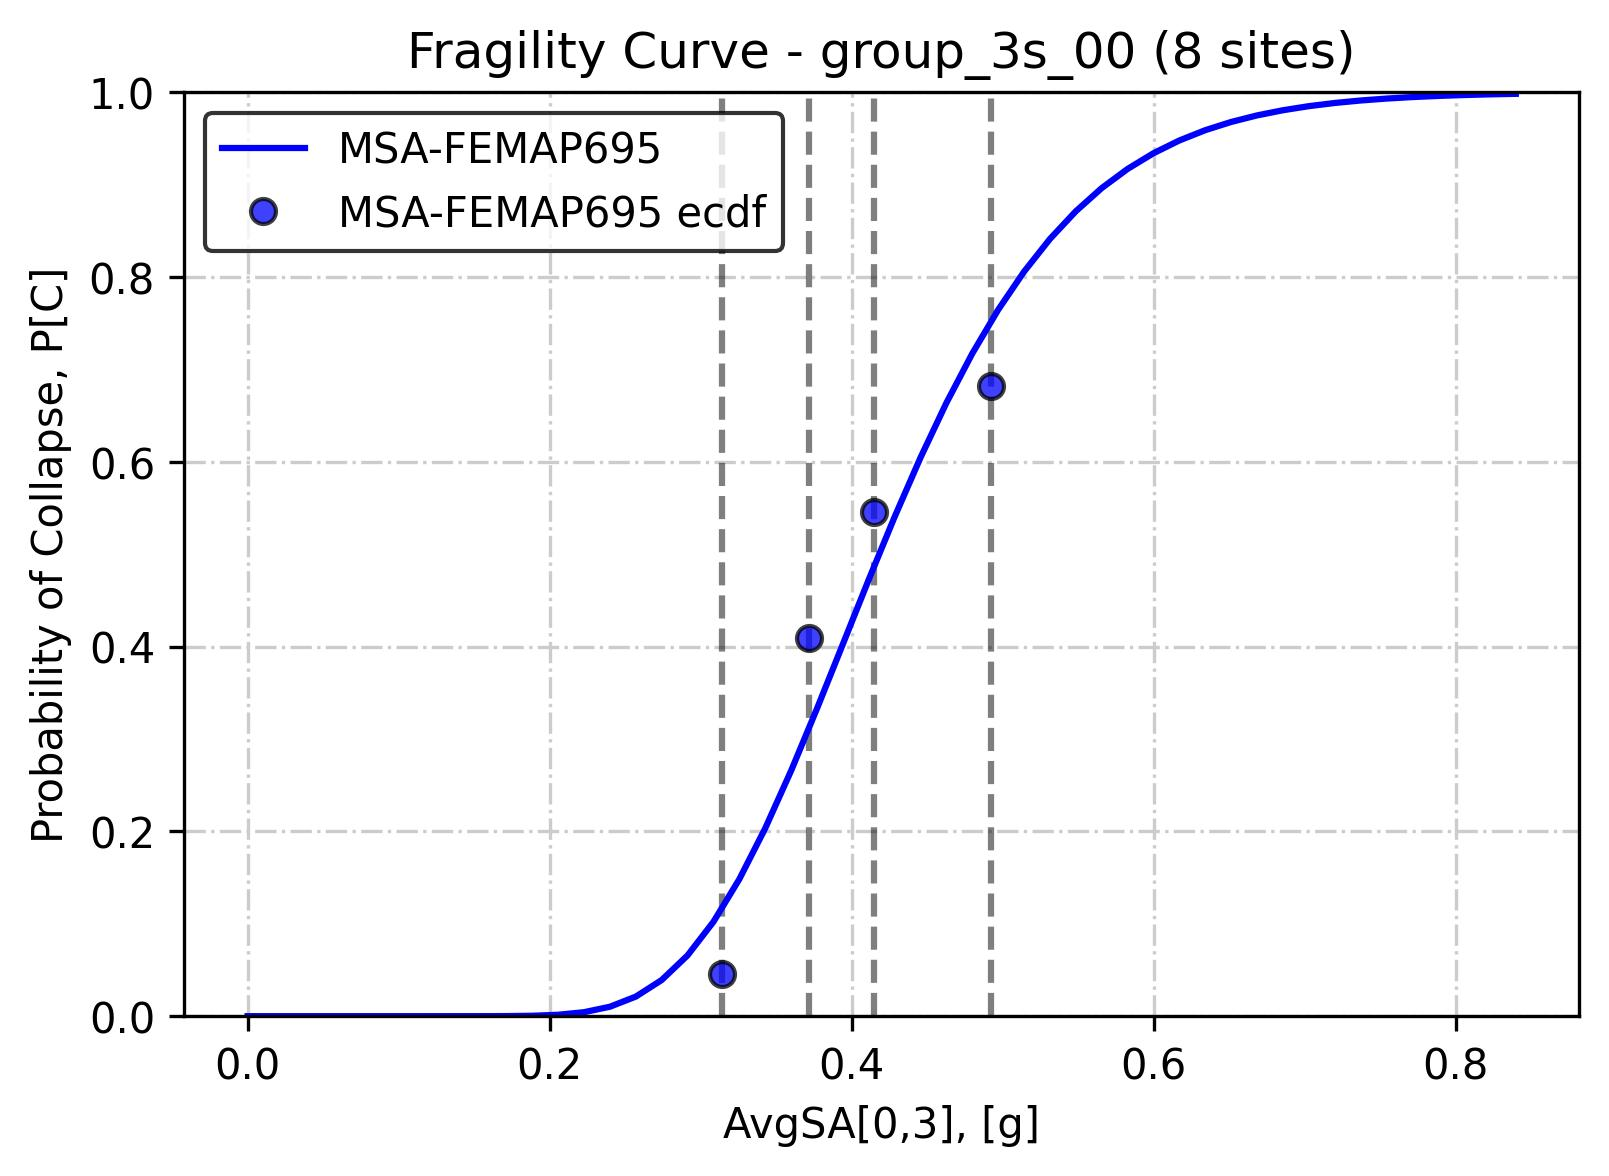

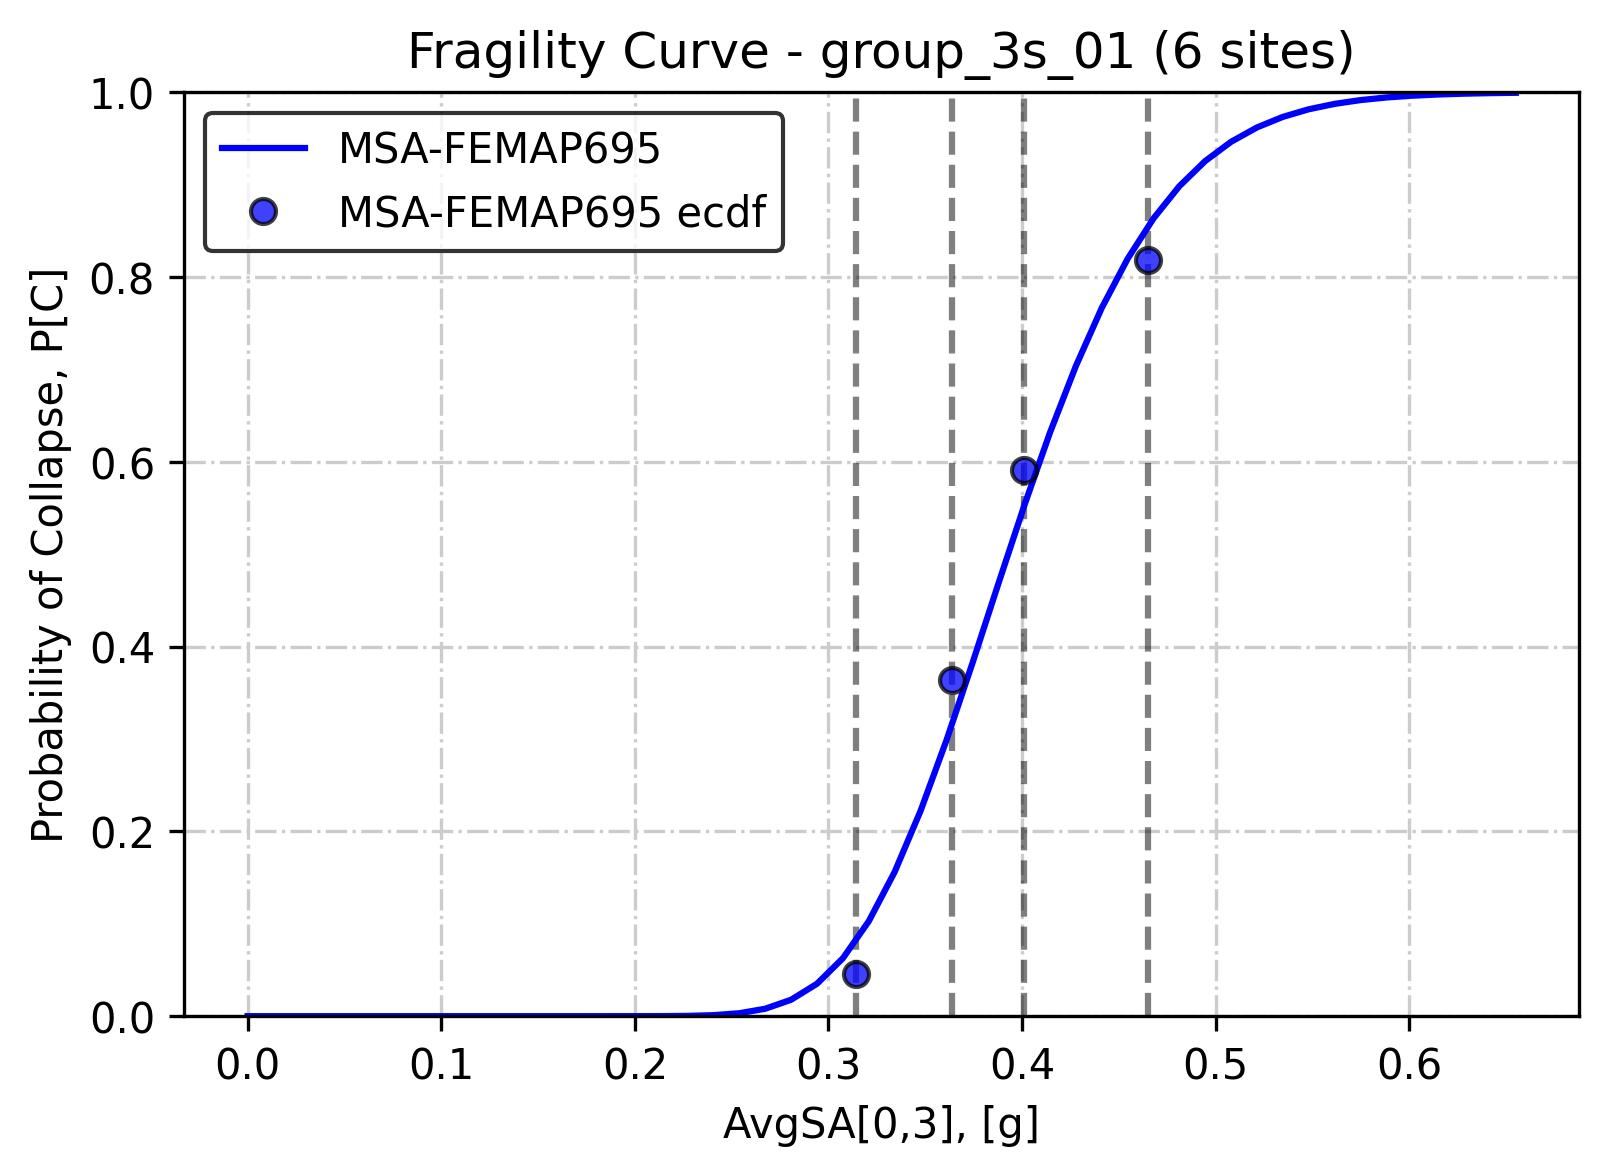

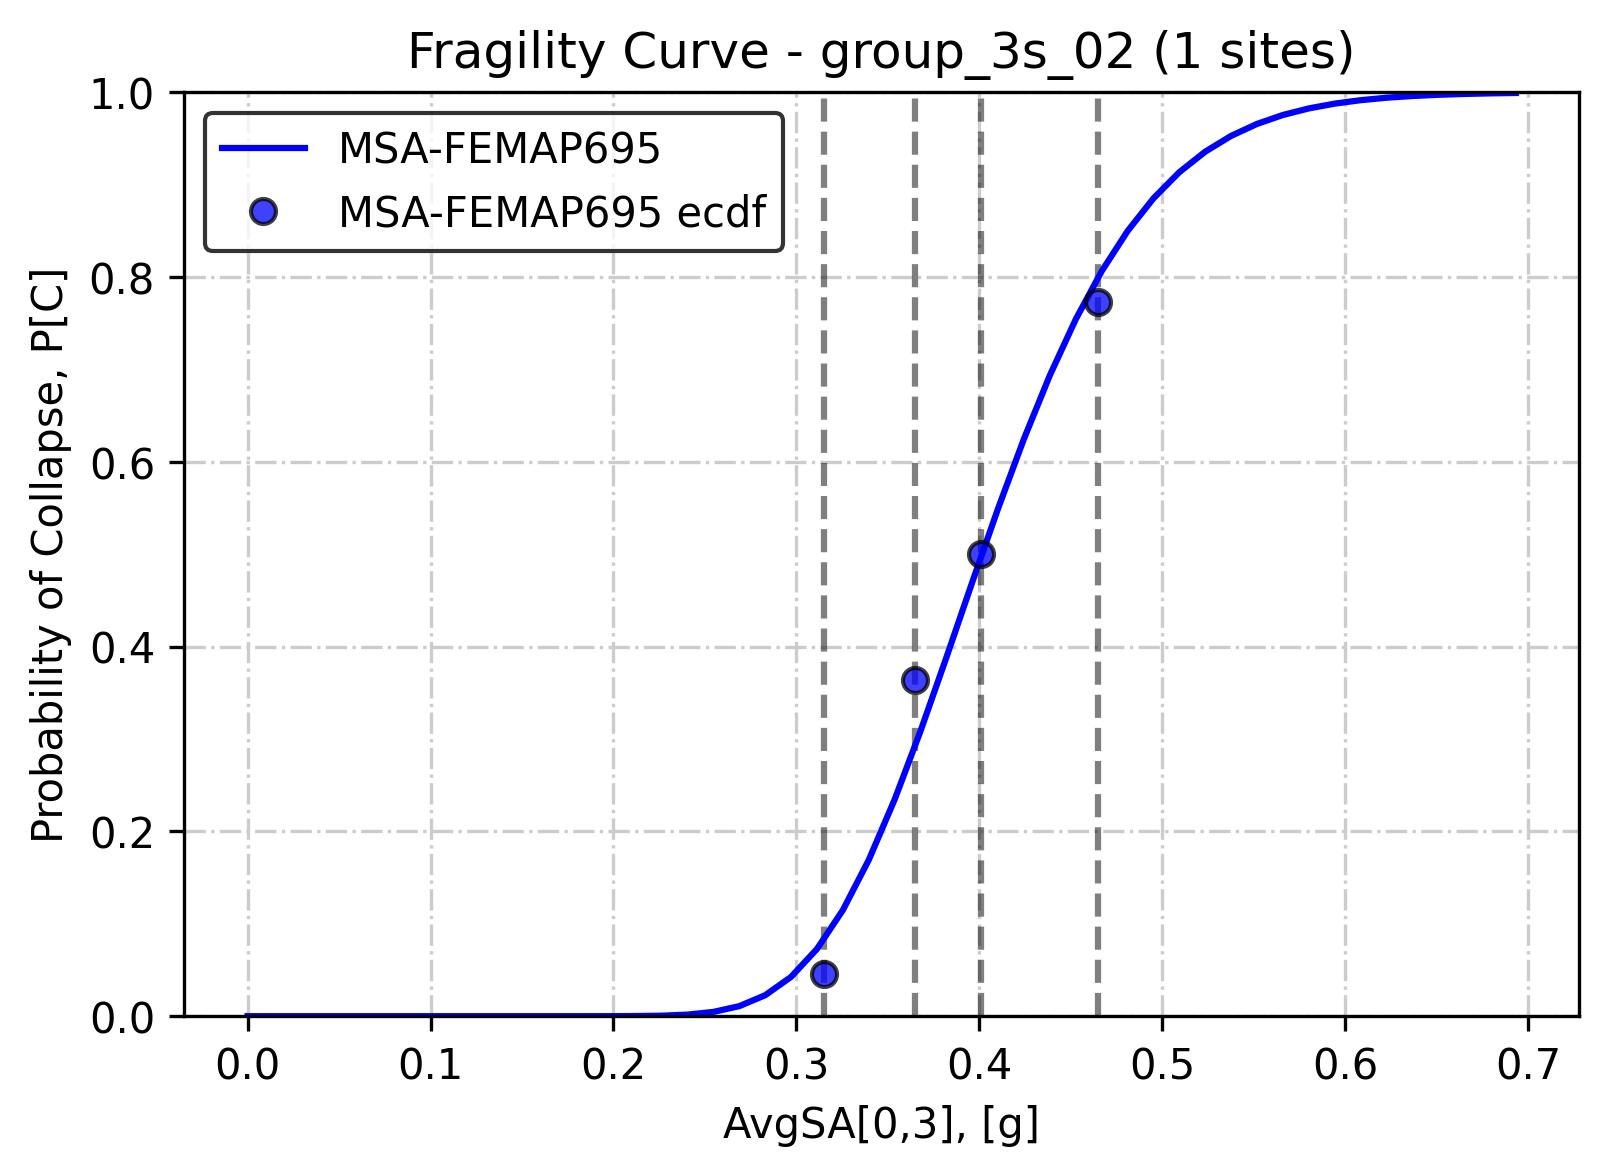

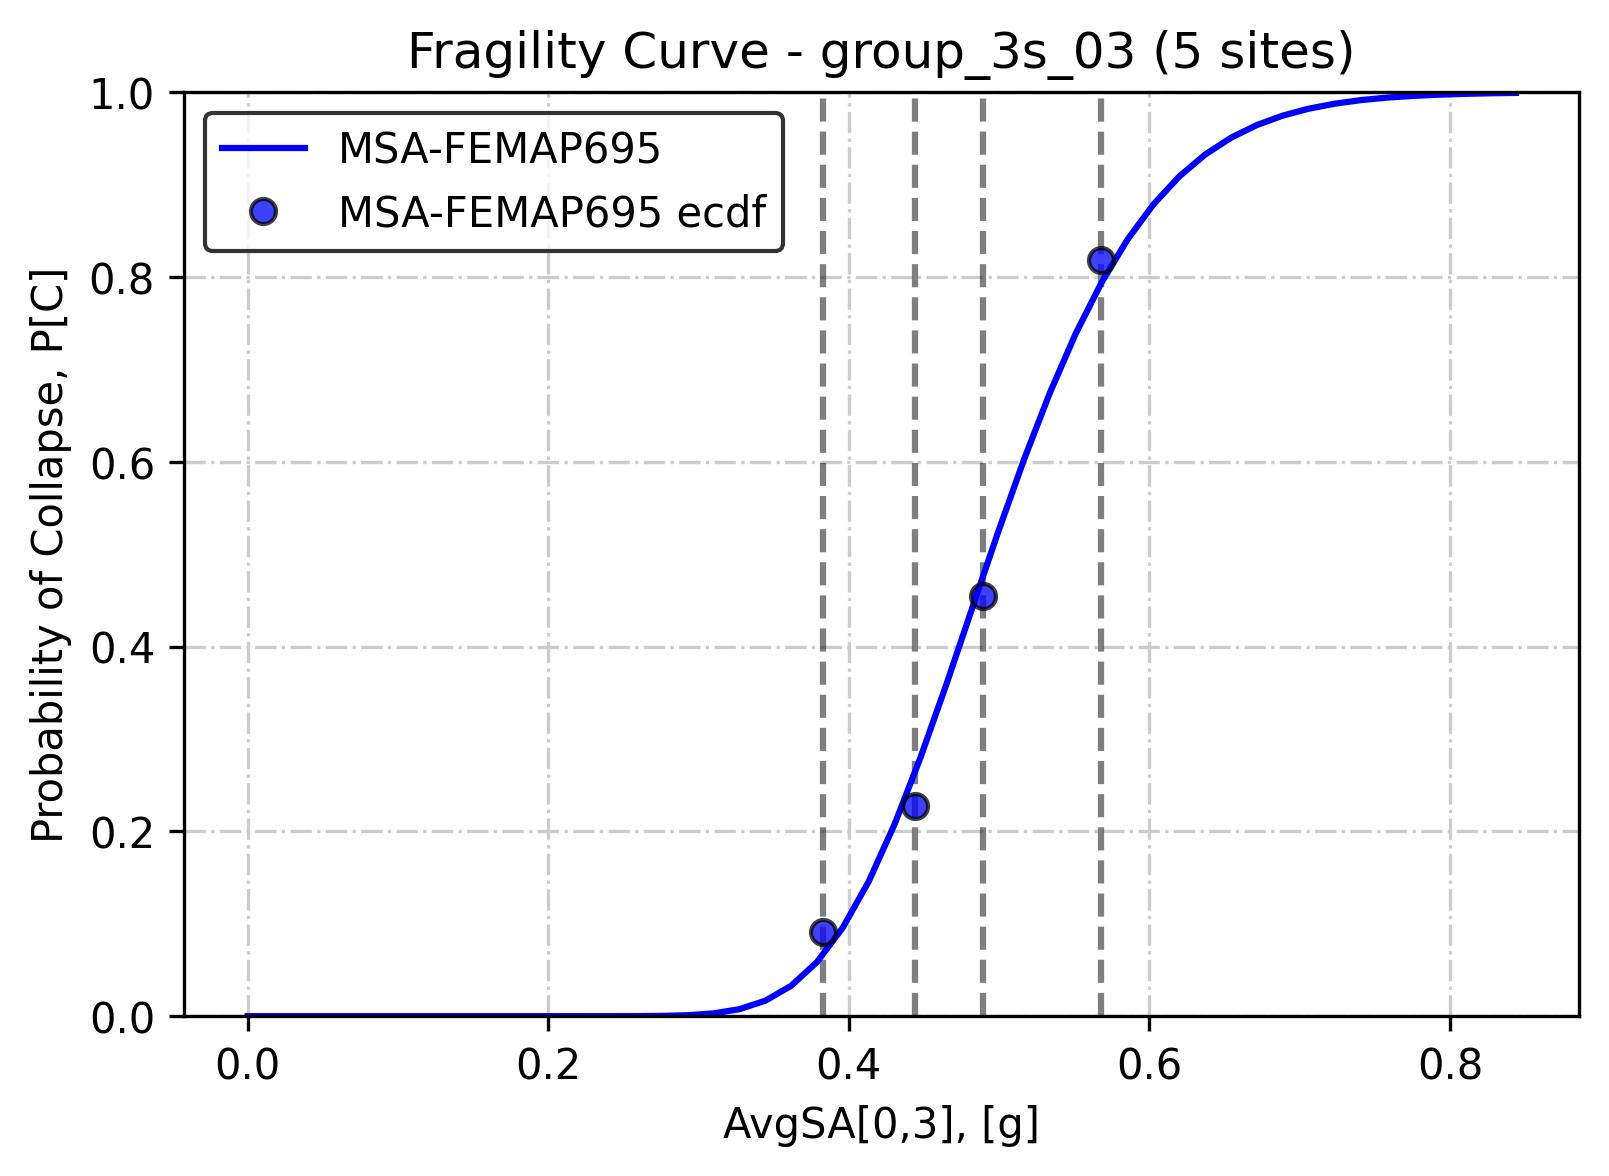

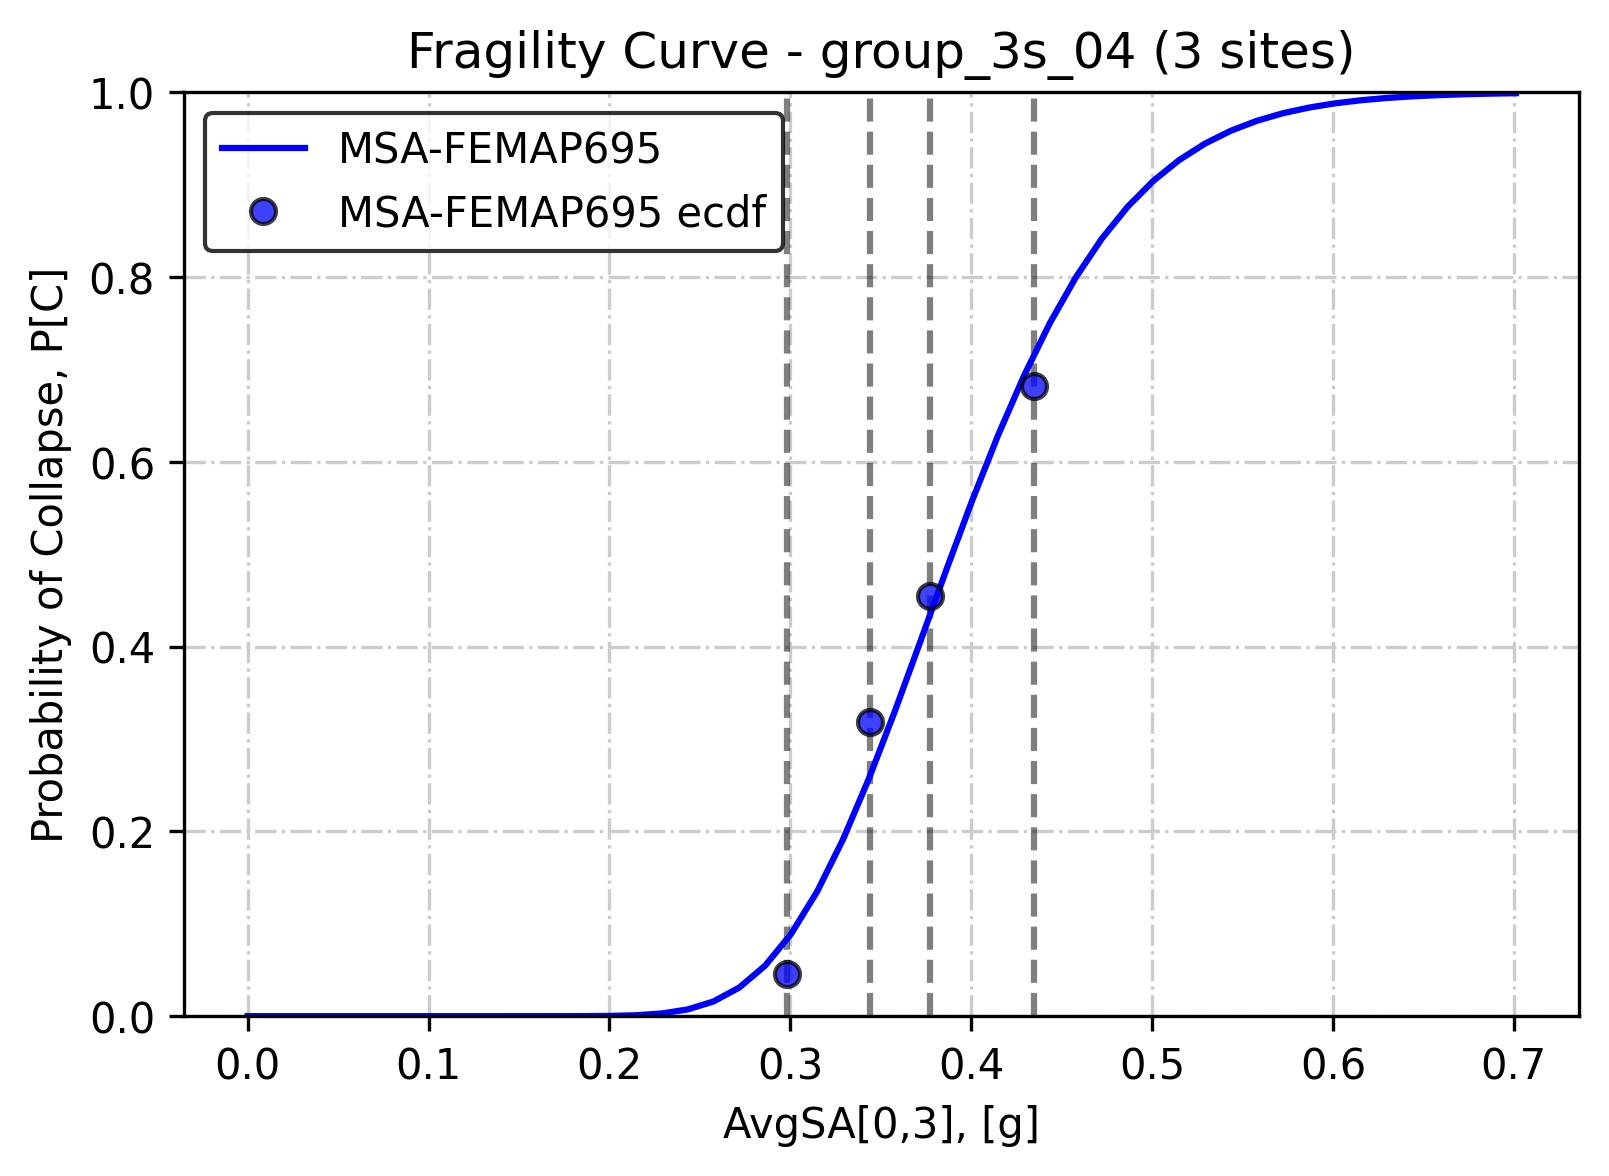

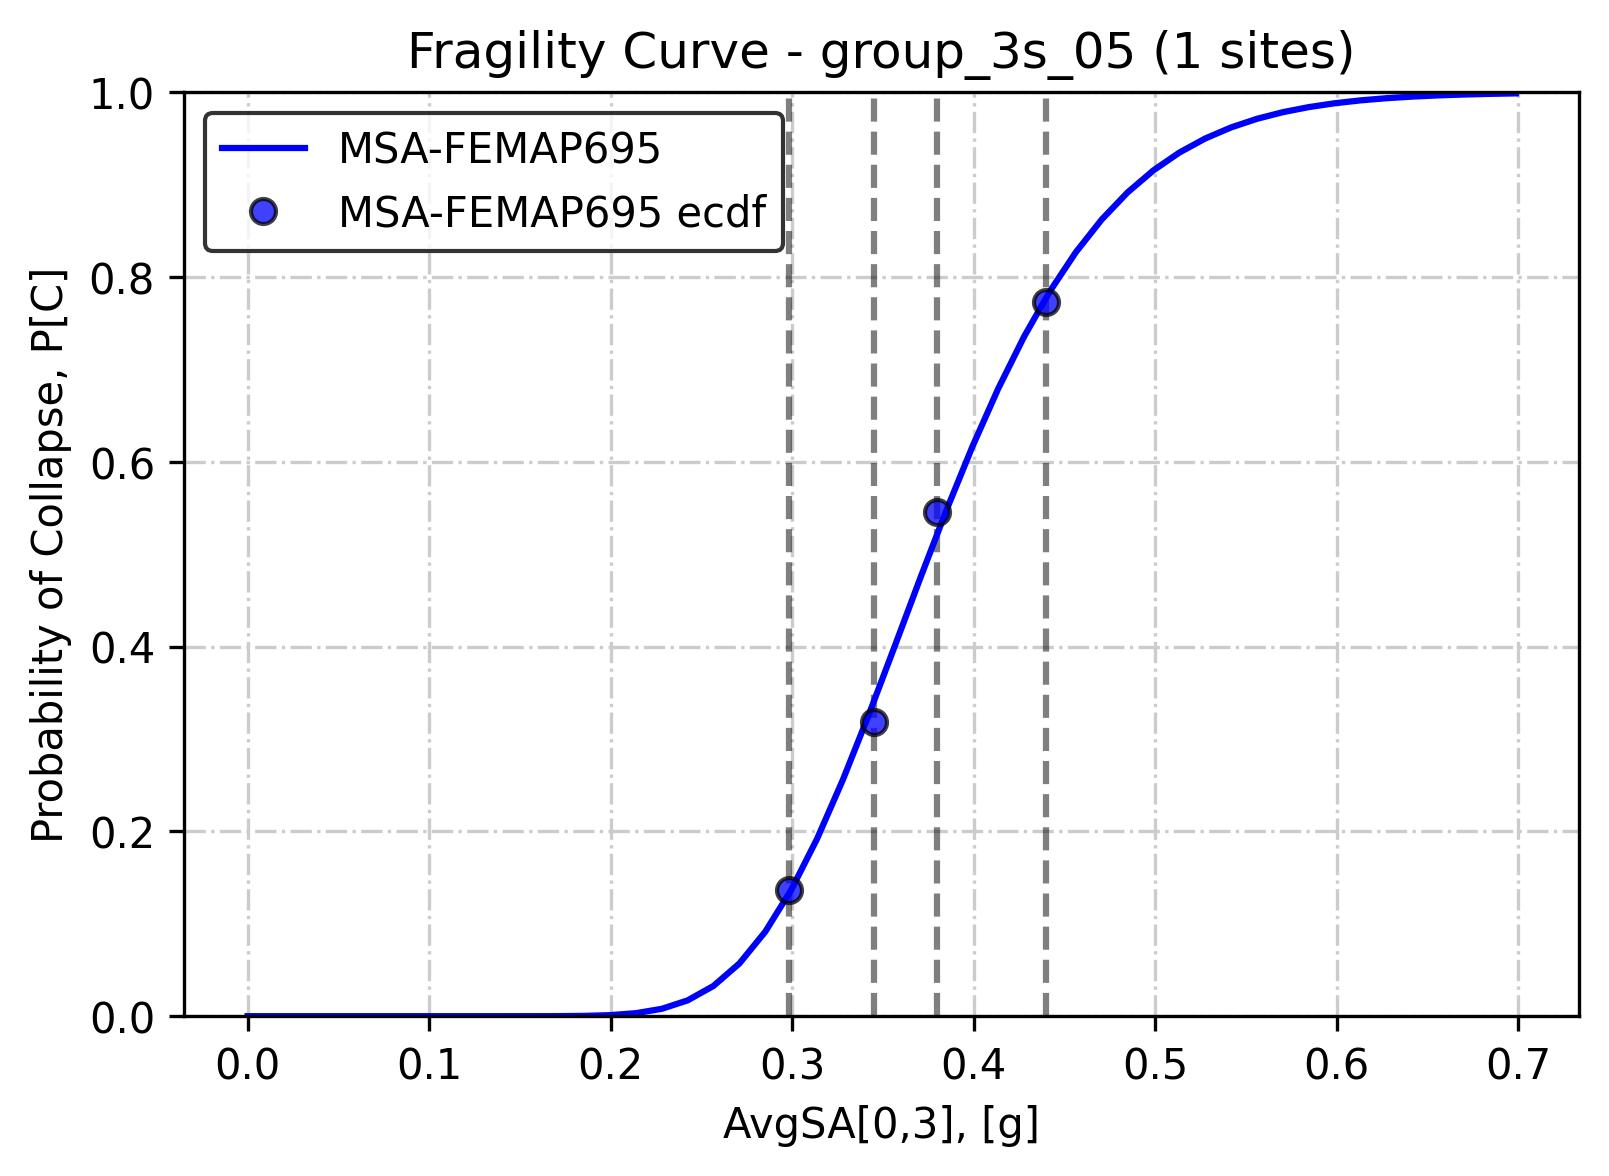

showing 6 of 25 figure(s); all of them are in C:\Users\clemettn\Documents\phd\results\07_group_msa_femap695


In [10]:
# Show the figures a few at a time, so a full 51-group run does not flood the notebook.
# Every figure is on disk under FIG_ROOT regardless of what is displayed here.
MAX_FIGS_SHOWN = 6

shown = sorted(group_results)[:MAX_FIGS_SHOWN]
for n, gid in shown:
    fp = plot_path(n, gid)
    if fp.is_file():
        display(Image(filename=str(fp), width=520))
print(f"showing {len(shown)} of {len(group_results)} figure(s); all of them are in "
      f"{FIG_ROOT}")

## 4. Fragility-curve definition check

Which groups the MSA-FEMAP695 stripes failed to bracket collapse for, reported separately
for each storey count. `054` aimed the four stripes at **P[C] = 0.15, 0.40, 0.60, 0.85**
by inverting the representative's `ida_femap695` AvgSA_03 fragility, so a failure here
means the MSA collapse capacity came out somewhere the IDA did not predict.

Every group is still fanned out in §5 whatever the verdict, and the flag travels into both
summary CSVs.

### The remediation file

For each **failing tail** — a group short only at the top gets one entry, one short at both
ends gets two — the IML the *fitted MSA* curve puts at `REMEDIATION_POCS` is written to

`data_processed/09_structure_fragility_curves/wp1_design_groups/group_msa_femap695_additional_stripes.csv`

| column | |
|---|---|
| `group`, `storeys`, `group_id` | the design group; `group_id` is what `054` keys on |
| `n_sites`, `sites` | what the extra stripe buys |
| `tail` | `low` / `high` |
| `target_poc` | 0.15 or 0.85 — outside the 0.2 / 0.8 pass-fail band, so the new stripe has a buffer |
| `iml` | the IML [g], rounded to `IML_DECIMALS` (the resolution the stripe filename encodes) |
| `msa_median`, `msa_dispersion`, `pc_min`, `pc_max` | the curve the suggestion came from |

The aim comes from the **MSA** fit, not from the `ida_femap695` fragility `054` inverted for
the original four stripes: that fragility is precisely what mis-placed them, because the MSA
came out with more dispersion than the IDA predicted.

This is not `060` §5. There is no hazard curve behind these stripes, so there are no reserve
stripes, no disaggregation grid and no ceiling — the record set is fixed and simply rescaled,
so any IML can be run. The loop is `061` → `054` → the MSA batch → `061`.

The file is **always rewritten**, with a header and no rows when every group is well defined,
so `054` can never act on a stale suggestion.

In [11]:
checks = []
for (n, gid), fc in sorted(group_results.items()):
    pc = fc["efc"][1, :]
    row = {
        "group": group_folder_name(n, gid),
        "storeys": n,
        "group_id": gid,
        "n_sites": len(members[(n, gid)]),
        "median": float(fc["median"]),
        "dispersion": float(fc["dispersion"]),
        "pc_min": float(pc.min()),
        "pc_max": float(pc.max()),
        "needs_low": bool(pc.min() >= PC_LOWER_THRESHOLD),
        "needs_high": bool(pc.max() <= PC_UPPER_THRESHOLD),
    }
    row["well_defined"] = not (row["needs_low"] or row["needs_high"])
    checks.append(row)

check = pd.DataFrame(checks)

print("Fragility-curve definition check")
print(f"  thresholds: max P[C] must exceed {PC_UPPER_THRESHOLD:.2f}, "
      f"min P[C] must fall below {PC_LOWER_THRESHOLD:.2f}")

for n in STOREYS:
    sub = check[check["storeys"] == n] if not check.empty else check
    print(f"\n{n}s groups - {len(sub)} assessed")
    if sub.empty:
        print("  no MSA-FEMAP695 fragility curves found.")
        continue
    lt = sub.loc[sub["needs_high"], "group"].tolist()
    gt = sub.loc[sub["needs_low"], "group"].tolist()
    print(f"  max P[C] <= {PC_UPPER_THRESHOLD:.2f} (upper tail not reached) - "
          f"{len(lt)} group(s): {', '.join(lt) if lt else '-'}")
    print(f"  min P[C] >= {PC_LOWER_THRESHOLD:.2f} (lower tail not reached) - "
          f"{len(gt)} group(s): {', '.join(gt) if gt else '-'}")
    n_bad = int((~sub["well_defined"]).sum())
    n_sites_bad = int(sub.loc[~sub["well_defined"], "n_sites"].sum())
    print(f"  well defined: {len(sub) - n_bad}/{len(sub)}  "
          f"({n_bad} group(s) fail at least one threshold, covering "
          f"{n_sites_bad} site(s))")

Fragility-curve definition check
  thresholds: max P[C] must exceed 0.80, min P[C] must fall below 0.20

3s groups - 25 assessed
  max P[C] <= 0.80 (upper tail not reached) - 16 group(s): group_3s_00, group_3s_02, group_3s_04, group_3s_05, group_3s_06, group_3s_07, group_3s_08, group_3s_09, group_3s_10, group_3s_12, group_3s_13, group_3s_14, group_3s_16, group_3s_18, group_3s_20, group_3s_21
  min P[C] >= 0.20 (lower tail not reached) - 3 group(s): group_3s_09, group_3s_10, group_3s_16
  well defined: 9/25  (16 group(s) fail at least one threshold, covering 34 site(s))

5s groups - 0 assessed
  no MSA-FEMAP695 fragility curves found.


In [12]:
# One row per failing tail: the IML the fitted MSA curve puts at the remediation target.
# The aim comes from the MSA fit, not from the ida_femap695 fragility nb 054 inverted for
# the original four stripes - that fragility is what mis-placed them.
extra_rows = []
for row in (check[~check["well_defined"]].itertuples() if not check.empty else []):
    for tail, needs in (("low", row.needs_low), ("high", row.needs_high)):
        if not needs:
            continue
        poc = REMEDIATION_POCS[tail]
        extra_rows.append({
            "group": row.group,
            "storeys": row.storeys,
            "group_id": row.group_id,
            "n_sites": row.n_sites,
            "sites": " ".join(str(s) for s in members[(row.storeys, row.group_id)]),
            "tail": tail,
            "target_poc": poc,
            "iml": round(float(lognorm.ppf(poc, s=row.dispersion, scale=row.median)),
                         IML_DECIMALS),
            "msa_median": row.median,
            "msa_dispersion": row.dispersion,
            "pc_min": row.pc_min,
            "pc_max": row.pc_max,
        })

COLUMNS = ["group", "storeys", "group_id", "n_sites", "sites", "tail", "target_poc",
           "iml", "msa_median", "msa_dispersion", "pc_min", "pc_max"]
additional = pd.DataFrame(extra_rows, columns=COLUMNS)
if not additional.empty:
    additional = additional.sort_values(["storeys", "group_id", "tail"])

# Written even when empty (header only), so nb 054 cannot act on a stale suggestion.
ADDITIONAL_STRIPES_CSV.parent.mkdir(parents=True, exist_ok=True)
additional.to_csv(ADDITIONAL_STRIPES_CSV, index=False)

if check.empty:
    print("no groups processed - nothing to check")
    print(f"wrote an empty {ADDITIONAL_STRIPES_CSV.name}")
elif additional.empty:
    print("every group's stripes bracket collapse - no extra stripes needed")
    print(f"wrote an empty {ADDITIONAL_STRIPES_CSV.name}")
else:
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(additional.to_string(index=False))
    n_groups = additional["group"].nunique()
    print(f"\nwrote {len(additional)} extra stripe(s) over {n_groups} group(s) to "
          f"{ADDITIONAL_STRIPES_CSV}")
    print("\nACTION REQUIRED - these are suggestions only, nothing has been analysed yet:")
    print("  1. re-run nb 054, which reads this file and writes the extra stripe")
    print("     selections alongside its four (and refreshes the group folders on D:);")
    print("  2. re-run the MSA-FEMAP695 batch (msa_AvgSA03_femap695.py). The runner's")
    print("     resume = True reuses every (stripe, record) pair already analysed, so only")
    print("     the new stripes actually run;")
    print("  3. re-run THIS notebook to refit the affected groups and fan them back out.")

      group  storeys  group_id  n_sites                sites tail  target_poc   iml  msa_median  msa_dispersion  pc_min  pc_max
group_3s_00        3         0        8 0 4 8 19 25 26 27 29 high       0.850 0.536       0.418           0.240   0.045   0.682
group_3s_02        3         2        1                    3 high       0.850 0.481       0.401           0.175   0.045   0.773
group_3s_04        3         4        3              9 20 22 high       0.850 0.476       0.389           0.193   0.045   0.682
group_3s_05        3         5        1                   12 high       0.850 0.465       0.376           0.207   0.136   0.773
group_3s_06        3         6        2                13 28 high       0.850 0.471       0.375           0.220   0.136   0.727
group_3s_07        3         7        1                   14 high       0.850 0.466       0.376           0.208   0.136   0.773
group_3s_08        3         8        1                   15 high       0.850 0.456       0.383         

## 5. Fan the group fragility out to its member sites

Each group's fragility is copied to **every** member site as
`site_{ii}/{tag}_msa_femap695_collapsefragility_AvgSA_03.json`, next to the site's `msa`
and `ida_femap695` files, so anything downstream stays on per-site paths and never has to
learn about groups.

The per-site manifest fingerprints the **group fragility JSON**, not the source on `D:` —
a site file is stale exactly when its group's fragility changed, which also means the
fan-out works with the analysis drive detached.

In [13]:
def site_fragility_path(n: int, site: int) -> Path:
    tag = structure_tag(n, site)
    return (OUT_ROOT / f"site_{int(site)}"
            / f"{tag}_{MSA_TAG}_collapsefragility_{GM_SET}.json")


site_results: dict[tuple[int, int], dict] = {}          # (storeys, site) -> fragility
site_group: dict[tuple[int, int], tuple[int, int]] = {}
fanout_status = {"cached": 0, "computed": 0}

if not FANOUT_TO_SITES:
    print("FANOUT_TO_SITES is False - only the group-level files were written")
else:
    for (n, gid), fc in sorted(group_results.items()):
        name = group_folder_name(n, gid)
        src = group_fragility_path(n, gid)
        for site in members[(n, gid)]:
            fp = site_fragility_path(n, site)
            fp.parent.mkdir(parents=True, exist_ok=True)
            out, status = json_load_or_compute(
                fp,
                fingerprint(group_fragility=src, group=name,
                            site=int(site), storeys=int(n)),
                lambda fc=fc: fc,
                force=FORCE_RECOMPUTE,
                input_paths={"group_fragility": src},
            )
            fanout_status[status] += 1
            site_results[(n, site)] = {k: np.array(v) if isinstance(v, list) else v
                                       for k, v in out.items()}
            site_group[(n, site)] = (n, gid)
        print(f"[fanout] {name} -> {len(members[(n, gid)])} site(s): "
              f"{fmt_sites(members[(n, gid)])}")

    print(f"\n{len(site_results)} structure(s) written to {OUT_ROOT} "
          f"({fanout_status['computed']} file(s) written, "
          f"{fanout_status['cached']} already current)")

[fanout] group_3s_00 -> 8 site(s): 0, 4, 8, 19, 25, 26, 27, 29
[fanout] group_3s_01 -> 6 site(s): 1, 2, 5, 6, 16, 23
[fanout] group_3s_02 -> 1 site(s): 3


[fanout] group_3s_03 -> 5 site(s): 7, 10, 11, 18, 24
[fanout] group_3s_04 -> 3 site(s): 9, 20, 22
[fanout] group_3s_05 -> 1 site(s): 12
[fanout] group_3s_06 -> 2 site(s): 13, 28
[fanout] group_3s_07 -> 1 site(s): 14


[fanout] group_3s_08 -> 1 site(s): 15
[fanout] group_3s_09 -> 2 site(s): 17, 21
[fanout] group_3s_10 -> 1 site(s): 30


[fanout] group_3s_11 -> 4 site(s): 31, 34, 43, 59
[fanout] group_3s_12 -> 4 site(s): 32, 33, 36, 50
[fanout] group_3s_13 -> 3 site(s): 35, 39, 58


[fanout] group_3s_14 -> 1 site(s): 37
[fanout] group_3s_15 -> 1 site(s): 38
[fanout] group_3s_16 -> 1 site(s): 40
[fanout] group_3s_17 -> 3 site(s): 41, 54, 57
[fanout] group_3s_18 -> 2 site(s): 42, 56


[fanout] group_3s_19 -> 3 site(s): 44, 46, 49
[fanout] group_3s_20 -> 2 site(s): 45, 52
[fanout] group_3s_21 -> 1 site(s): 47
[fanout] group_3s_22 -> 2 site(s): 48, 51
[fanout] group_3s_23 -> 1 site(s): 53


[fanout] group_3s_24 -> 1 site(s): 55

60 structure(s) written to C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_casestudy_sites (0 file(s) written, 60 already current)


### Coverage

Which (storey, site) structures ended up with an MSA-FEMAP695 fragility. Every site of
every storey count in `STOREYS` should appear exactly once; sites whose group has no MSA
run yet are listed as missing.

In [14]:
cov_rows = []
for n in STOREYS:
    all_sites = sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
    got = [s for s in all_sites if (n, s) in site_results]
    cov_rows.append({"storeys": n, "sites": len(all_sites), "with_fragility": len(got),
                     "missing": len(all_sites) - len(got),
                     "groups_processed": sum(1 for k in group_results if k[0] == n),
                     "groups_total": int((groups["storeys"] == n).sum())})

coverage = pd.DataFrame(cov_rows)
print(coverage.to_string(index=False))
for n in STOREYS:
    miss = [s for s in sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
            if (n, s) not in site_results]
    if miss:
        print(f"{n}s missing sites: {fmt_sites(miss)}")

 storeys  sites  with_fragility  missing  groups_processed  groups_total
       3     60              60        0                25            25
       5     60               0       60                 0            26
5s missing sites: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59


## 7. Summary tables

Both carry the collapse median in **g**, the dimensionless lognormal $\beta$, the P[C]
range the stripes actually spanned, and the well-definedness flag from §4:

- **group level** — one row per design group, with its member sites, to
  `wp1_design_groups/group_msa_femap695_collapsefragility_summary.csv`;
- **site level** — one row per structure, to
  `wp1_casestudy_sites/site_msa_femap695_collapsefragility_summary.csv`.

In [15]:
if check.empty:
    print("no groups processed - no group summary written")
else:
    group_summary = (check
                     .assign(sites=[" ".join(str(s) for s in members[(int(r.storeys),
                                                                     int(r.group_id))])
                                    for r in check.itertuples()])
                     .loc[:, ["group", "storeys", "n_sites", "sites", "median",
                              "dispersion", "pc_min", "pc_max", "well_defined"]]
                     .set_index("group")
                     .sort_values(["storeys", "median"]))
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(group_summary.to_string())
    GROUP_SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
    group_summary.to_csv(GROUP_SUMMARY_CSV)
    print(f"\nwrote {GROUP_SUMMARY_CSV}")

             storeys  n_sites                 sites  median  dispersion  pc_min  pc_max  well_defined
group                                                                                                
group_3s_06        3        2                 13 28   0.375       0.220   0.136   0.727         False
group_3s_05        3        1                    12   0.376       0.207   0.136   0.773         False
group_3s_07        3        1                    14   0.376       0.208   0.136   0.773         False
group_3s_08        3        1                    15   0.383       0.169   0.045   0.773         False
group_3s_04        3        3               9 20 22   0.389       0.193   0.045   0.682         False
group_3s_01        3        6         1 2 5 6 16 23   0.393       0.160   0.045   0.818          True
group_3s_02        3        1                     3   0.401       0.175   0.045   0.773         False
group_3s_00        3        8  0 4 8 19 25 26 27 29   0.418       0.240   0.045   



wrote C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups\group_msa_femap695_collapsefragility_summary.csv


In [16]:
flags = check.set_index(["storeys", "group_id"])["well_defined"] if not check.empty else {}

site_rows = {}
for (n, site), fc in sorted(site_results.items()):
    key = site_group[(n, site)]
    site_rows[structure_tag(n, site)] = {
        "storeys": n,
        "site": site,
        "group": group_folder_name(*key),
        "median": float(fc["median"]),
        "dispersion": float(fc["dispersion"]),
        "pc_min": float(fc["efc"][1, :].min()),
        "pc_max": float(fc["efc"][1, :].max()),
        "well_defined": bool(flags[key]),
    }

site_summary = pd.DataFrame.from_dict(site_rows, orient="index")
if site_summary.empty:
    print("no structures written - no site summary written")
else:
    site_summary.index.name = "structure"
    site_summary = site_summary.sort_values(["storeys", "site"])
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(site_summary.to_string())
    SITE_SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
    site_summary.to_csv(SITE_SUMMARY_CSV)
    print(f"\nwrote {SITE_SUMMARY_CSV}")

                   storeys  site        group  median  dispersion  pc_min  pc_max  well_defined
structure                                                                                      
3s_cbf_dc2_site0         3     0  group_3s_00   0.418       0.240   0.045   0.682         False
3s_cbf_dc2_site1         3     1  group_3s_01   0.393       0.160   0.045   0.818          True
3s_cbf_dc2_site2         3     2  group_3s_01   0.393       0.160   0.045   0.818          True
3s_cbf_dc2_site3         3     3  group_3s_02   0.401       0.175   0.045   0.773         False
3s_cbf_dc2_site4         3     4  group_3s_00   0.418       0.240   0.045   0.682         False
3s_cbf_dc2_site5         3     5  group_3s_01   0.393       0.160   0.045   0.818          True
3s_cbf_dc2_site6         3     6  group_3s_01   0.393       0.160   0.045   0.818          True
3s_cbf_dc2_site7         3     7  group_3s_03   0.494       0.170   0.091   0.818          True
3s_cbf_dc2_site8         3     8  group_